In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import os
from tqdm import tqdm

## 量化全序列的mi分布

In [2]:
df = pd.read_csv('/home/rsun@ZHANGroup.local/hqy_new/not_used_0112/filter_all/summary/res_all.csv', index_col = 0)
df.shape  # 8959648 sites

(8959648, 7)

In [ ]:


# idx = df['mi'] >= 0.35
# df_sub = df.loc[idx,:]

# idx = (df_sub.iloc[:,:5] > 0).sum(1) >=3
# df_sub = df_sub.loc[idx,:]
# df_sub

# tmp = {}
# for ele in df_sub.index:
#     x = ele.split('_')[0]
#     if x in tmp: 
#         continue 
#     else:
#         tmp[x] = 1
# print(len(tmp)) ## 716 个gene list

717


## 过滤前mi分布

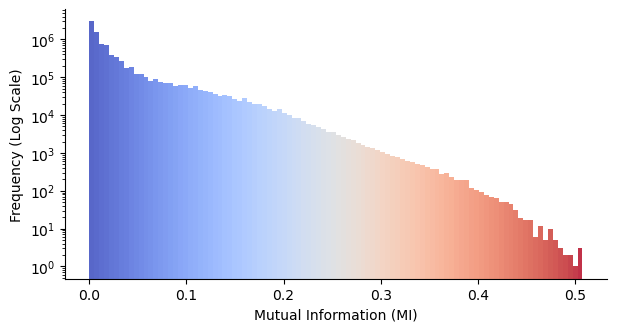

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

mi_values = df['mi'].values 
plt.figure(figsize=(7, 3.5))

# 1. 绘制直方图
N, bins, patches = plt.hist(mi_values, bins=100, log=True, edgecolor='none', alpha=0.85)

# 2. 根据 bin 的位置（X轴值）映射 coolwarm 渐变色
norm = plt.Normalize(bins.min(), bins.max())
cmap = plt.get_cmap('coolwarm')

for bin_edge, patch in zip(bins[:-1], patches):
    color = cmap(norm(bin_edge))
    patch.set_facecolor(color)

plt.xlabel('Mutual Information (MI)')
plt.ylabel('Frequency (Log Scale)')

# 3. 去除上方和右侧的边框线 (Spines)
ax = plt.gca() # 获取当前坐标轴对象
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 可选：如果您希望左侧和下侧的线条更细或颜色更淡，也可以在这里调整
# ax.spines['left'].set_linewidth(0.5)
# ax.spines['bottom'].set_linewidth(0.5)

plt.grid(False)

# 4. 保存为透明背景的 SVG
# bbox_inches='tight' 去除图片周围多余的白边
# transparent=True 确保背景透明
plt.savefig('MI_info.svg', bbox_inches='tight', transparent=True)

plt.show()